# LSTM MODEL

In [ ]:
import pickle
import numpy as np

with open('/content/processed_data.pkl', 'rb') as f:
    payload = pickle.load(f)

if isinstance(payload, dict):
    X_train = payload['X_train']
    X_test = payload['X_test']
    y_train = payload['y_train']
    y_test = payload['y_test']
    target_scaler = payload['target_scaler']
    feature_cols = payload.get('feature_cols', [])
else:
    # Backward compatibility with old tuple format
    X_train, X_test, y_train, y_test, scaler = payload
    target_scaler = scaler
    feature_cols = ['Close']

# Keep this alias for compatibility with downstream cells
scaler = target_scaler

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Features:', feature_cols)
# File loaded successfully.

X_train shape: (1094, 60, 11)
X_test shape: (274, 60, 11)
Features: ['Close', 'Open', 'High', 'Low', 'Volume', 'MA20', 'MA50', 'RSI', 'BB_upper', 'BB_lower', 'Returns']


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# LSTM model building (stabilized for less overfitting)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(48, return_sequences=True),
    Dropout(0.3),

    LSTM(24, return_sequences=False),
    Dropout(0.3),

    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dense(1)
])

optimizer = Adam(learning_rate=5e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='huber')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 48)         │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24)             │         7,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,945 (74.00 KB)

 Trainable params: 18,945 (74.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks for stable validation behavior
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("models/lstm_model.h5", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
# Train the model with chronological validation split
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

history = model.fit(
    X_tr, y_tr,
    epochs=1200,
    batch_size=8,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    shuffle=False,
    verbose=1
)

Epoch 1/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0030

117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0042 - val_loss: 0.0020 - learning_rate: 5.0000e-04
Epoch 2/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0058 - val_loss: 0.0031 - learning_rate: 5.0000e-04
Epoch 3/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.0050 - val_loss: 0.0036 - learning_rate: 5.0000e-04
Epoch 4/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0046 - val_loss: 0.0030 - learning_rate: 5.0000e-04
Epoch 5/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0038 - val_loss: 0.0034 - learning_rate: 5.0000e-04
Epoch 6/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0035 - val_loss: 0.0026 - learning_rate: 5.0000e-04
Epoch 7/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0033 - val_loss: 0.0036 - learning_rate: 5.0000e-04
Epoch 8/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0028 - val_loss: 0.0024 - learning_rate: 5.0000e-04
Epoch 9/1200
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0036
Epoch 9

117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0026 - val_loss: 0.0020 - learning_rate: 2.5000e-04
Epoch 11/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.0023 - val_loss: 0.0023 - learning_rate: 2.5000e-04
Epoch 12/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.0020 - val_loss: 0.0025 - learning_rate: 2.5000e-04
Epoch 13/1200
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0015

117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0018 - val_loss: 0.0017 - learning_rate: 2.5000e-04
Epoch 14/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0019 - val_loss: 0.0021 - learning_rate: 2.5000e-04
Epoch 15/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0018 - val_loss: 0.0023 - learning_rate: 2.5000e-04
Epoch 16/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0017 - val_loss: 0.0019 - learning_rate: 2.5000e-04
Epoch 17/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0018 - val_loss: 0.0023 - learning_rate: 2.5000e-04
Epoch 18/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0017 - val_loss: 0.0019 - learning_rate: 2.5000e-04
Epoch 19/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0017 - val_loss: 0.0020 - learning_rate: 2.5000e-04
Epoch 20/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0017 - val_loss: 0.0019 - learning_rate: 2.5000e-04
Epoch 21/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0013

117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0017 - val_loss: 0.0017 - learning_rate: 1.2500e-04
Epoch 23/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0016 - val_loss: 0.0019 - learning_rate: 1.2500e-04
Epoch 24/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0016 - val_loss: 0.0023 - learning_rate: 1.2500e-04
Epoch 25/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0015 - val_loss: 0.0020 - learning_rate: 1.2500e-04
Epoch 26/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0015 - val_loss: 0.0026 - learning_rate: 1.2500e-04
Epoch 27/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0015 - val_loss: 0.0023 - learning_rate: 1.2500e-04
Epoch 28/1200
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 0.0014 - val_loss: 0.0022 - learning_rate: 1.2500e-04
Epoch 29/1200
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0011
Epoch 29: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/ste

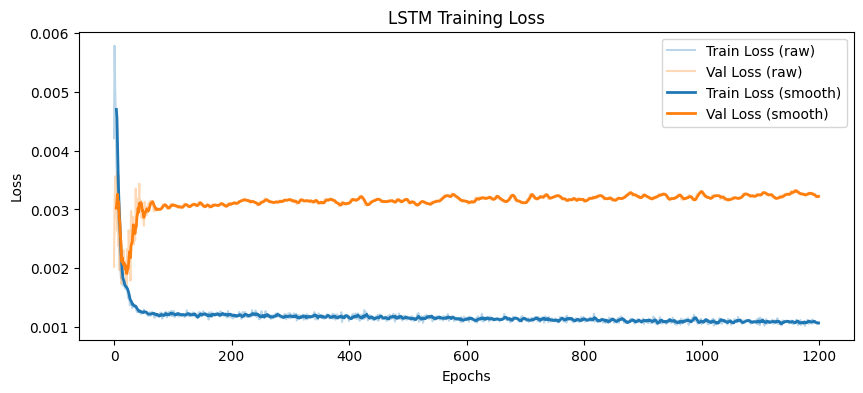

In [ ]:
# Plot training history (raw + smoothed)
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (raw)', color='tab:blue', alpha=0.3)
plt.plot(val_loss, label='Val Loss (raw)', color='tab:orange', alpha=0.3)

window = 5
if len(train_loss) >= window:
    train_smooth = np.convolve(train_loss, np.ones(window)/window, mode='valid')
    val_smooth = np.convolve(val_loss, np.ones(window)/window, mode='valid')
    x = np.arange(window - 1, len(train_loss))
    plt.plot(x, train_smooth, label='Train Loss (smooth)', color='tab:blue', linewidth=2)
    plt.plot(x, val_smooth, label='Val Loss (smooth)', color='tab:orange', linewidth=2)

plt.title('LSTM Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the best saved model
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_model = load_model('models/lstm_model.h5', compile=False)
y_pred_scaled = best_model.predict(X_test, verbose=0)

# Inverse transform back to price values
y_pred = target_scaler.inverse_transform(y_pred_scaled).reshape(-1)
y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / np.clip(np.abs(y_actual), 1e-8, None))) * 100

print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')
print(f'MAPE : {mape:.2f}%')

RMSE : 1607.97
MAE  : 1439.94
MAPE : 7.46%


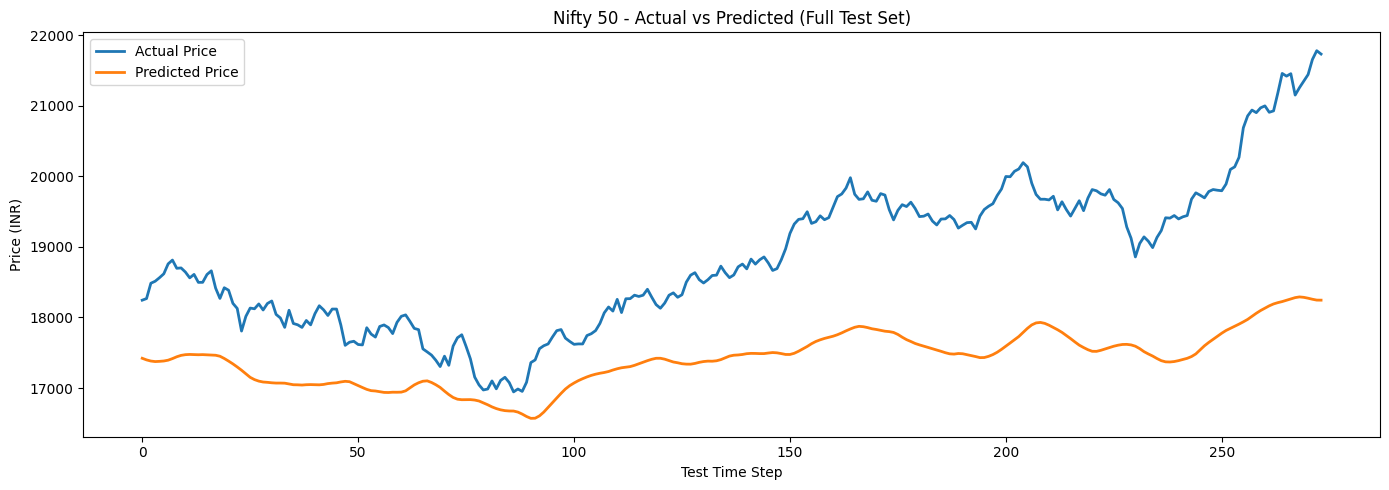

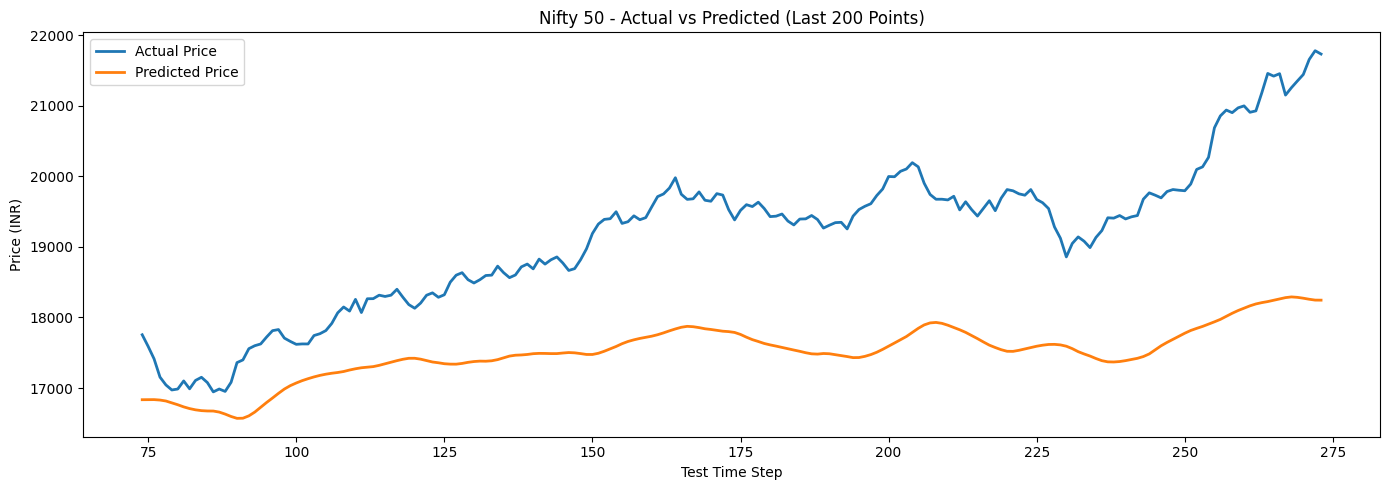

In [ ]:
# Plot predicted vs actual (recent window + full test trend)
import matplotlib.pyplot as plt

n = len(y_actual)
x = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(x, y_actual, label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x, y_pred, label='Predicted Price', color='tab:orange', linewidth=2)
plt.title('Nifty 50 - Actual vs Predicted (Full Test Set)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional zoom: last 200 points for easier visual comparison
zoom = min(200, n)
plt.figure(figsize=(14, 5))
plt.plot(x[-zoom:], y_actual[-zoom:], label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x[-zoom:], y_pred[-zoom:], label='Predicted Price', color='tab:orange', linewidth=2)
plt.title(f'Nifty 50 - Actual vs Predicted (Last {zoom} Points)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()


# GRU MODEL

In [ ]:
# GRU model building (stabilized for less overfitting)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

gru_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(48, return_sequences=True),
    Dropout(0.3),

    GRU(24, return_sequences=False),
    Dropout(0.3),

    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dense(1)
])

optimizer = Adam(learning_rate=5e-4, clipnorm=1.0)
gru_model.compile(optimizer=optimizer, loss='huber')
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 48)         │         8,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 24)             │         5,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,529 (56.75 KB)

 Trainable params: 14,529 (56.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks for stable validation behavior (GRU)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

gru_callbacks = [
    ModelCheckpoint("models/gru_model.h5", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
# Train the GRU model with chronological validation split
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

gru_history = gru_model.fit(
    X_tr, y_tr,
    epochs=1200,
    batch_size=4,
    validation_data=(X_val, y_val),
    callbacks=gru_callbacks,
    shuffle=False,
    verbose=1
)

Epoch 1/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0085

233/233 ━━━━━━━━━━━━━━━━━━━━ 67s 51ms/step - loss: 0.0082 - val_loss: 0.0023 - learning_rate: 5.0000e-04
Epoch 2/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 0.0053 - val_loss: 0.0029 - learning_rate: 5.0000e-04
Epoch 3/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0042

233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.0043 - val_loss: 0.0019 - learning_rate: 5.0000e-04
Epoch 4/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 0.0035 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 5/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0031

233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 0.0031 - val_loss: 0.0018 - learning_rate: 5.0000e-04
Epoch 6/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.0028 - val_loss: 0.0029 - learning_rate: 5.0000e-04
Epoch 7/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 0.0024 - val_loss: 0.0034 - learning_rate: 5.0000e-04
Epoch 8/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0024 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 9/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 0.0023 - val_loss: 0.0030 - learning_rate: 5.0000e-04
Epoch 10/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0020 - val_loss: 0.0058 - learning_rate: 5.0000e-04
Epoch 11/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0022

233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - loss: 0.0021 - val_loss: 0.0013 - learning_rate: 5.0000e-04
Epoch 12/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - loss: 0.0020 - val_loss: 0.0018 - learning_rate: 5.0000e-04
Epoch 13/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - loss: 0.0018 - val_loss: 0.0026 - learning_rate: 5.0000e-04
Epoch 14/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.0016 - val_loss: 0.0028 - learning_rate: 5.0000e-04
Epoch 15/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0018

...

233/233 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - loss: 7.0897e-04 - val_loss: 6.1096e-04 - learning_rate: 6.2500e-05
Epoch 49/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 6.4397e-04 - val_loss: 7.2162e-04 - learning_rate: 6.2500e-05
Epoch 50/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.3271e-04

233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 6.5547e-04 - val_loss: 5.5943e-04 - learning_rate: 6.2500e-05
Epoch 51/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 6.2051e-04 - val_loss: 5.6801e-04 - learning_rate: 6.2500e-05
Epoch 52/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - loss: 6.1069e-04 - val_loss: 5.7770e-04 - learning_rate: 6.2500e-05
Epoch 53/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 5.9628e-04 - val_loss: 6.0963e-04 - learning_rate: 6.2500e-05
Epoch 54/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 4.2869e-04

233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 6.4402e-04 - val_loss: 5.0097e-04 - learning_rate: 6.2500e-05
Epoch 55/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 6.3009e-04 - val_loss: 5.2637e-04 - learning_rate: 6.2500e-05
Epoch 56/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.2665e-04

233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 6.1254e-04 - val_loss: 5.0019e-04 - learning_rate: 6.2500e-05
Epoch 57/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 5.5950e-04 - val_loss: 6.2880e-04 - learning_rate: 6.2500e-05
Epoch 58/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 5.8657e-04 - val_loss: 5.2892e-04 - learning_rate: 6.2500e-05
Epoch 59/1200
232/233 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 4.0228e-04

233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 5.7690e-04 - val_loss: 4.5976e-04 - learning_rate: 6.2500e-05
Epoch 60/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 5.9828e-04 - val_loss: 5.4211e-04 - learning_rate: 6.2500e-05
Epoch 61/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 5.7037e-04 - val_loss: 6.5735e-04 - learning_rate: 6.2500e-05
Epoch 62/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 4.2956e-04
Epoch 62: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 5.9227e-04 - val_loss: 5.0954e-04 - learning_rate: 6.2500e-05
Epoch 63/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 5.6520e-04 - val_loss: 5.0105e-04 - learning_rate: 3.1250e-05
Epoch 64/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 5.8448e-04 - val_loss: 4.8874e-04 - learning_rate: 3.1250e-05
Epoch 65/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - loss: 6.1970e-04 - val_loss: 4.6769e-04 - learning_rate

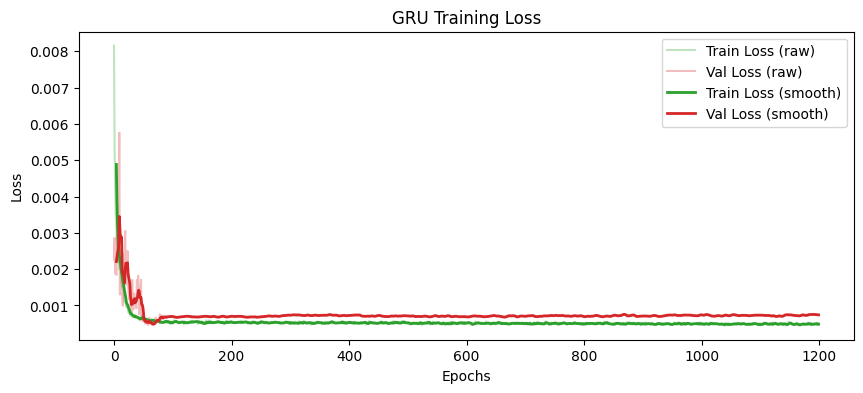

In [ ]:
# Plot GRU training history (raw + smoothed)
import matplotlib.pyplot as plt

train_loss = gru_history.history['loss']
val_loss = gru_history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (raw)', color='tab:green', alpha=0.3)
plt.plot(val_loss, label='Val Loss (raw)', color='tab:red', alpha=0.3)

window = 5
if len(train_loss) >= window:
    train_smooth = np.convolve(train_loss, np.ones(window)/window, mode='valid')
    val_smooth = np.convolve(val_loss, np.ones(window)/window, mode='valid')
    x = np.arange(window - 1, len(train_loss))
    plt.plot(x, train_smooth, label='Train Loss (smooth)', color='tab:green', linewidth=2)
    plt.plot(x, val_smooth, label='Val Loss (smooth)', color='tab:red', linewidth=2)

plt.title('GRU Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the best saved GRU model
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_gru_model = load_model('models/gru_model.h5', compile=False)
gru_y_pred_scaled = best_gru_model.predict(X_test, verbose=0)

# Inverse transform back to price values
gru_y_pred = target_scaler.inverse_transform(gru_y_pred_scaled).reshape(-1)
gru_y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

gru_rmse = np.sqrt(mean_squared_error(gru_y_actual, gru_y_pred))
gru_mae = mean_absolute_error(gru_y_actual, gru_y_pred)
gru_mape = np.mean(np.abs((gru_y_actual - gru_y_pred) / np.clip(np.abs(gru_y_actual), 1e-8, None))) * 100

print(f'GRU RMSE : {gru_rmse:.2f}')
print(f'GRU MAE  : {gru_mae:.2f}')
print(f'GRU MAPE : {gru_mape:.2f}%')

GRU RMSE : 802.14
GRU MAE  : 670.64
GRU MAPE : 3.45%


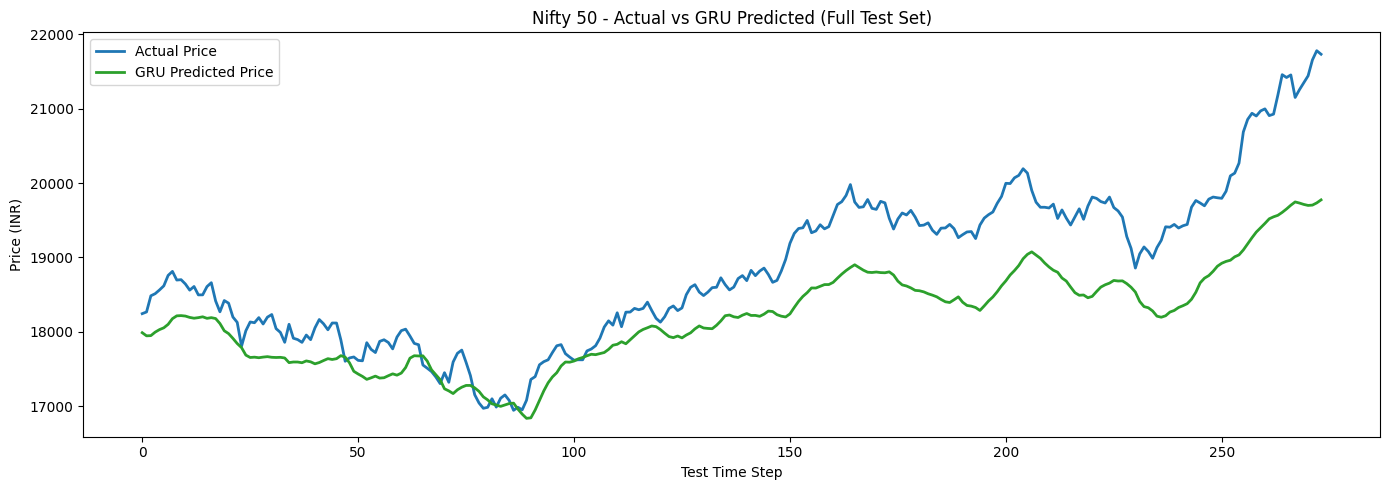

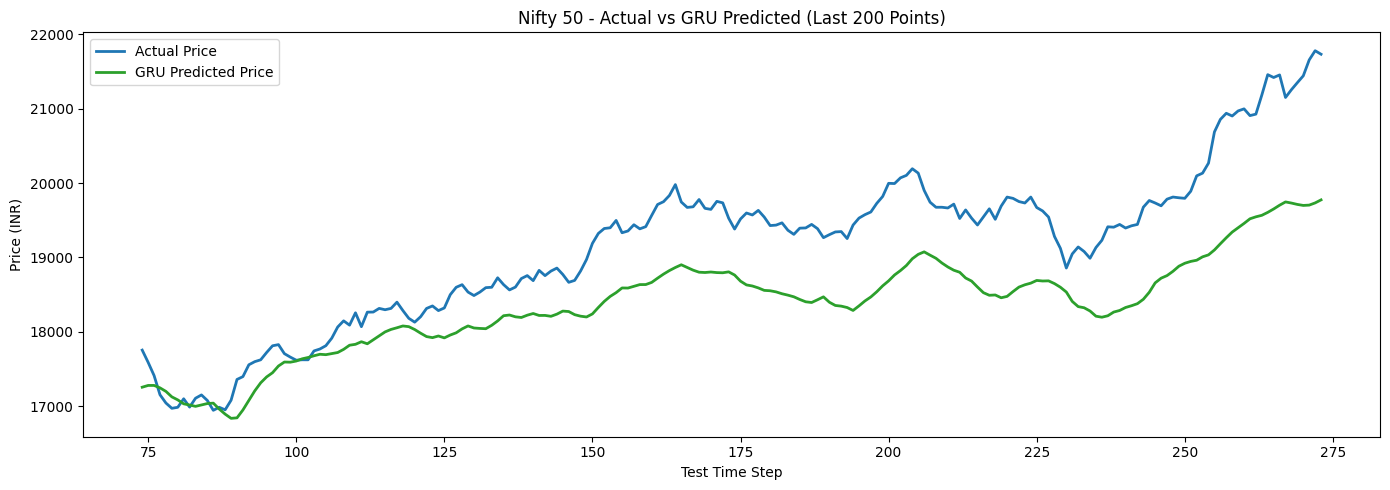

In [ ]:
# Plot GRU predicted vs actual (recent window + full test trend)
import matplotlib.pyplot as plt

n = len(gru_y_actual)
x = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(x, gru_y_actual, label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x, gru_y_pred, label='GRU Predicted Price', color='tab:green', linewidth=2)
plt.title('Nifty 50 - Actual vs GRU Predicted (Full Test Set)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional zoom: last 200 points for easier visual comparison
zoom = min(200, n)
plt.figure(figsize=(14, 5))
plt.plot(x[-zoom:], gru_y_actual[-zoom:], label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x[-zoom:], gru_y_pred[-zoom:], label='GRU Predicted Price', color='tab:green', linewidth=2)
plt.title(f'Nifty 50 - Actual vs GRU Predicted (Last {zoom} Points)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# TRANSFORMER MODEL

In [ ]:
# Transformer model building with Multi-Head Self-Attention
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

# Build Transformer-based model
def create_transformer_model(input_shape, num_heads=4, ff_dim=128):
    inputs = Input(shape=input_shape)
    x = inputs

    # Multi-Head Self-Attention
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=32)(x, x)
    attention_output = Dropout(0.3)(attention_output)
    x = LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed Forward Network
    ff_output = Dense(ff_dim, activation='relu')(x)
    ff_output = Dropout(0.3)(ff_output)
    ff_output = Dense(input_shape[-1])(ff_output)
    x = LayerNormalization(epsilon=1e-6)(x + ff_output)

    # Global pooling and dense layers
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1)(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

transformer_model = create_transformer_model((X_train.shape[1], X_train.shape[2]))
optimizer = Adam(learning_rate=5e-4, clipnorm=1.0)
transformer_model.compile(optimizer=optimizer, loss='huber')
transformer_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 60, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 11)    │      6,027 │ input_layer_3[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 60, 11)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 11)    │          0 │ input_layer_3[0]… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 11)    │         22 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 60, 128)   │      1,536 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 60, 128)   │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 60, 11)    │      1,419 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 11)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 11)    │         22 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 11)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        768 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      2,080 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         33 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,907 (46.51 KB)

 Trainable params: 11,907 (46.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks for stable validation behavior (Transformer)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

transformer_callbacks = [
    ModelCheckpoint("models/transformer_model.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
# Train the Transformer model with chronological validation split
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

transformer_history = transformer_model.fit(
    X_tr, y_tr,
    epochs=1200,
    batch_size=4,
    validation_data=(X_val, y_val),
    callbacks=transformer_callbacks,
    shuffle=False,
    verbose=1
)

# Save the trained model
transformer_model.save('models/transformer_model.keras')

Epoch 1/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0070 - val_loss: 0.0046 - learning_rate: 5.0000e-04
Epoch 2/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0056 - val_loss: 0.0014 - learning_rate: 5.0000e-04
Epoch 3/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0064 - val_loss: 0.0013 - learning_rate: 5.0000e-04
Epoch 4/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0080 - val_loss: 0.0018 - learning_rate: 5.0000e-04
Epoch 5/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0063 - val_loss: 0.0033 - learning_rate: 5.0000e-04
Epoch 6/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0065 - val_loss: 0.0017 - learning_rate: 5.0000e-04
Epoch 7/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0072 - val_loss: 0.0059 - learning_rate: 5.0000e-04
Epoch 8/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0067 - val_loss: 0.0023 - learning_rate: 5.0000e-04
Epoch 9/1200
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0077 

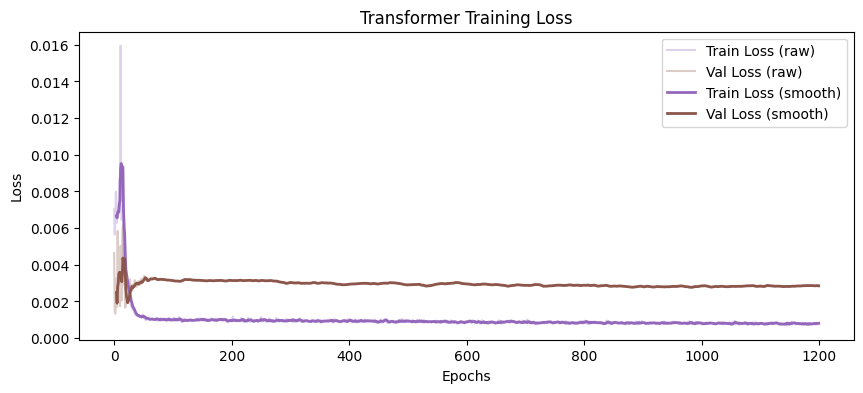

In [ ]:
# Plot Transformer training history (raw + smoothed)
import matplotlib.pyplot as plt

train_loss = transformer_history.history['loss']
val_loss = transformer_history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (raw)', color='tab:purple', alpha=0.3)
plt.plot(val_loss, label='Val Loss (raw)', color='tab:brown', alpha=0.3)

window = 5
if len(train_loss) >= window:
    train_smooth = np.convolve(train_loss, np.ones(window)/window, mode='valid')
    val_smooth = np.convolve(val_loss, np.ones(window)/window, mode='valid')
    x = np.arange(window - 1, len(train_loss))
    plt.plot(x, train_smooth, label='Train Loss (smooth)', color='tab:purple', linewidth=2)
    plt.plot(x, val_smooth, label='Val Loss (smooth)', color='tab:brown', linewidth=2)

plt.title('Transformer Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the best saved Transformer model
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_transformer_model = load_model('models/transformer_model.keras', compile=False)
transformer_y_pred_scaled = best_transformer_model.predict(X_test, verbose=0)

# Inverse transform back to price values
transformer_y_pred = target_scaler.inverse_transform(transformer_y_pred_scaled).reshape(-1)
transformer_y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

transformer_rmse = np.sqrt(mean_squared_error(transformer_y_actual, transformer_y_pred))
transformer_mae = mean_absolute_error(transformer_y_actual, transformer_y_pred)
transformer_mape = np.mean(np.abs((transformer_y_actual - transformer_y_pred) / np.clip(np.abs(transformer_y_actual), 1e-8, None))) * 100

print(f'Transformer RMSE : {transformer_rmse:.2f}')
print(f'Transformer MAE  : {transformer_mae:.2f}')
print(f'Transformer MAPE : {transformer_mape:.2f}%')

Transformer RMSE : 2520.12
Transformer MAE  : 2304.06
Transformer MAPE : 11.96%


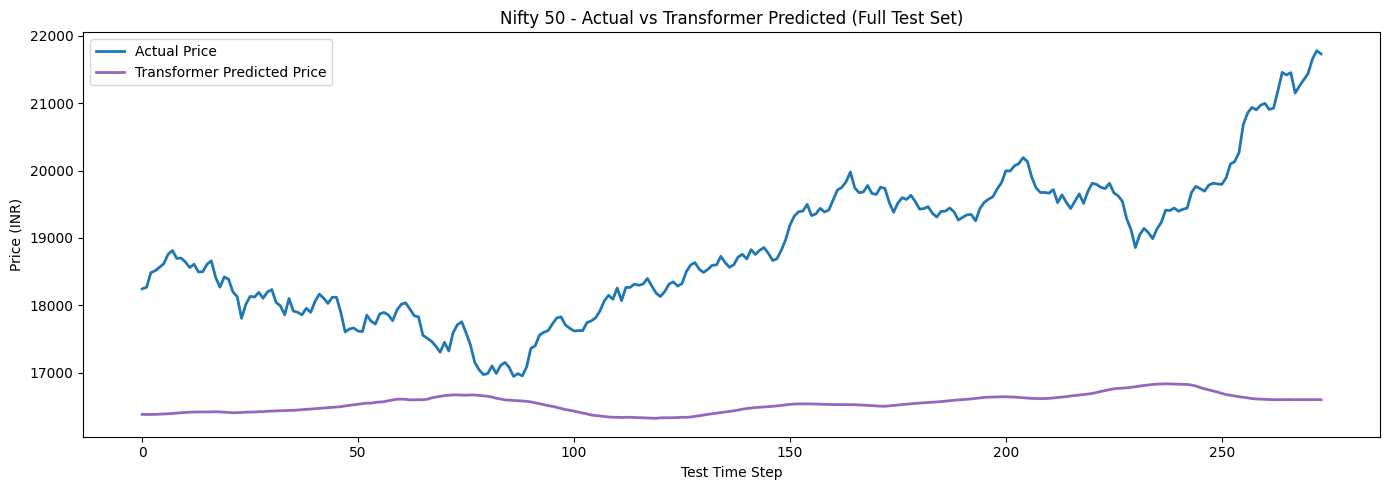

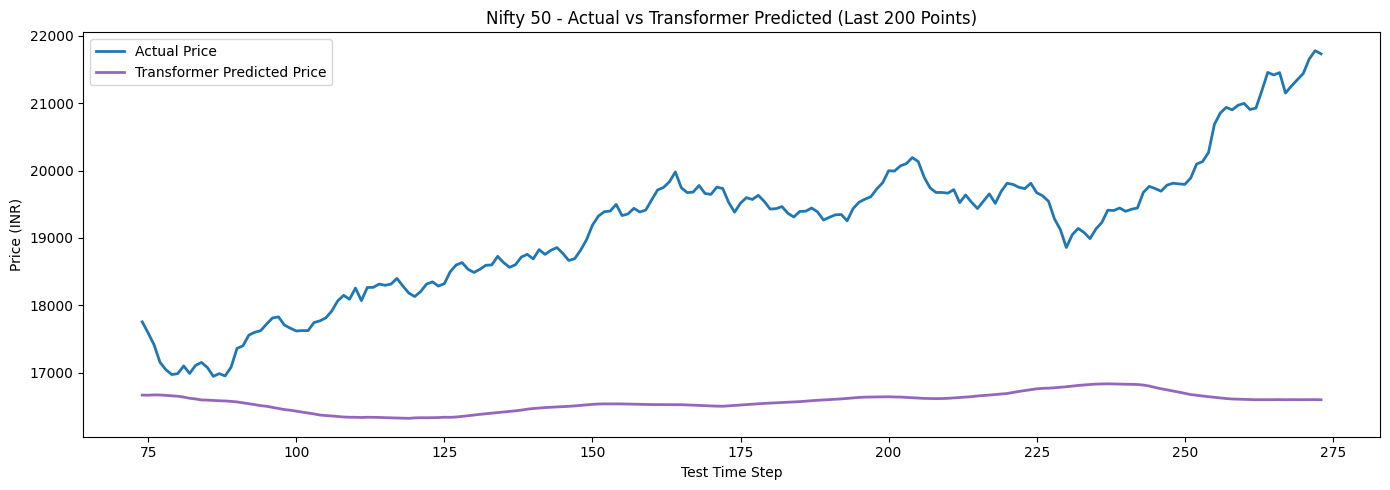

In [ ]:
# Plot Transformer predicted vs actual (recent window + full test trend)
import matplotlib.pyplot as plt

n = len(transformer_y_actual)
x = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(x, transformer_y_actual, label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x, transformer_y_pred, label='Transformer Predicted Price', color='tab:purple', linewidth=2)
plt.title('Nifty 50 - Actual vs Transformer Predicted (Full Test Set)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional zoom: last 200 points for easier visual comparison
zoom = min(200, n)
plt.figure(figsize=(14, 5))
plt.plot(x[-zoom:], transformer_y_actual[-zoom:], label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x[-zoom:], transformer_y_pred[-zoom:], label='Transformer Predicted Price', color='tab:purple', linewidth=2)
plt.title(f'Nifty 50 - Actual vs Transformer Predicted (Last {zoom} Points)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# CNN + LSTM MODEL

In [ ]:
# CNN + LSTM model building (ultra high-capacity setup)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

cnn_lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    Conv1D(filters=256, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),

    LSTM(256, return_sequences=True),
    Dropout(0.2),
    LSTM(192, return_sequences=True),
    Dropout(0.2),
    LSTM(128, return_sequences=False),
    Dropout(0.2),

    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

optimizer = Adam(learning_rate=2e-4, clipnorm=1.0)
cnn_lstm_model.compile(optimizer=optimizer, loss='huber')
cnn_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 256)        │        14,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 60, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 192)        │       344,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 192)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,289,345 (4.92 MB)

 Trainable params: 1,288,321 (4.91 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [ ]:
# Callbacks for stable validation behavior (CNN + LSTM, full-epoch high-capacity)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, TerminateOnNaN

cnn_lstm_callbacks = [
    ModelCheckpoint("models/cnn_lstm_model.keras", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=20,
        min_lr=1e-7,
        verbose=1
    ),
    TerminateOnNaN()
]

In [ ]:
# Train the CNN + LSTM model with chronological validation split (maximum run)
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

cnn_lstm_epochs = 200
cnn_lstm_batch_size = 64

cnn_lstm_history = cnn_lstm_model.fit(
    X_tr, y_tr,
    epochs=cnn_lstm_epochs,
    batch_size=cnn_lstm_batch_size,
    validation_data=(X_val, y_val),
    callbacks=cnn_lstm_callbacks,
    shuffle=False,
    verbose=1
)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 846ms/step - loss: 0.0017 - val_loss: 0.0363 - learning_rate: 1.0000e-07
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 747ms/step - loss: 0.0017 - val_loss: 0.0360 - learning_rate: 1.0000e-07
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 743ms/step - loss: 0.0017 - val_loss: 0.0358 - learning_rate: 1.0000e-07
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 643ms/step - loss: 0.0017 - val_loss: 0.0357 - learning_rate: 1.0000e-07
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 675ms/step - loss: 0.0017 - val_loss: 0.0356 - learning_rate: 1.0000e-07
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 743ms/step - loss: 0.0017 - val_loss: 0.0354 - learning_rate: 1.0000e-07
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 734ms/step - loss: 0.0017 - val_loss: 0.0354 - learning_rate: 1.0000e-07
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 620ms/step - loss: 0.0017 - val_loss: 0.0353 - learning_rate: 1.0000e-07
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 712ms/step - loss: 0.0017 - va

In [ ]:
# Plot CNN + LSTM training history (raw + smoothed)
import matplotlib.pyplot as plt

train_loss = cnn_lstm_history.history['loss']
val_loss = cnn_lstm_history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (raw)', color='tab:cyan', alpha=0.3)
plt.plot(val_loss, label='Val Loss (raw)', color='tab:pink', alpha=0.3)

window = 5
if len(train_loss) >= window:
    train_smooth = np.convolve(train_loss, np.ones(window)/window, mode='valid')
    val_smooth = np.convolve(val_loss, np.ones(window)/window, mode='valid')
    x = np.arange(window - 1, len(train_loss))
    plt.plot(x, train_smooth, label='Train Loss (smooth)', color='tab:cyan', linewidth=2)
    plt.plot(x, val_smooth, label='Val Loss (smooth)', color='tab:pink', linewidth=2)

plt.title('CNN + LSTM Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the best saved CNN + LSTM model
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_cnn_lstm_model = load_model('models/cnn_lstm_model.keras', compile=False)
cnn_lstm_y_pred_scaled = best_cnn_lstm_model.predict(X_test, verbose=0)

# Inverse transform back to price values
cnn_lstm_y_pred = target_scaler.inverse_transform(cnn_lstm_y_pred_scaled).reshape(-1)
cnn_lstm_y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

cnn_lstm_rmse = np.sqrt(mean_squared_error(cnn_lstm_y_actual, cnn_lstm_y_pred))
cnn_lstm_mae = mean_absolute_error(cnn_lstm_y_actual, cnn_lstm_y_pred)
cnn_lstm_mape = np.mean(np.abs((cnn_lstm_y_actual - cnn_lstm_y_pred) / np.clip(np.abs(cnn_lstm_y_actual), 1e-8, None))) * 100

print(f'CNN+LSTM RMSE : {cnn_lstm_rmse:.2f}')
print(f'CNN+LSTM MAE  : {cnn_lstm_mae:.2f}')
print(f'CNN+LSTM MAPE : {cnn_lstm_mape:.2f}%')

In [ ]:
# Plot CNN + LSTM predicted vs actual (recent window + full test trend)
import matplotlib.pyplot as plt

n = len(cnn_lstm_y_actual)
x = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(x, cnn_lstm_y_actual, label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x, cnn_lstm_y_pred, label='CNN+LSTM Predicted Price', color='tab:cyan', linewidth=2)
plt.title('Nifty 50 - Actual vs CNN+LSTM Predicted (Full Test Set)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional zoom: last 200 points for easier visual comparison
zoom = min(200, n)
plt.figure(figsize=(14, 5))
plt.plot(x[-zoom:], cnn_lstm_y_actual[-zoom:], label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x[-zoom:], cnn_lstm_y_pred[-zoom:], label='CNN+LSTM Predicted Price', color='tab:cyan', linewidth=2)
plt.title(f'Nifty 50 - Actual vs CNN+LSTM Predicted (Last {zoom} Points)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()